In [2]:
import numpy as np
import os
import random
import platform
from PIL import Image, ImageDraw, ImageFont
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


c:\GitHub\ocr_easy_text\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
# ==========================================
# 2. PYTHON SCRIPT
# ==========================================

# --- CONFIGURATION ---
IMAGE_SIZE = 64
SAMPLES_PER_CHAR = 1000
FILENAME = "dataset_aligned.npz"
OUTPUT_PATH = FILENAME
PADDING = 10          # MATCHES YOUR OPENCV SCRIPT

In [ ]:
# =============================================================================
# Konfiguration
# =============================================================================

# Zeichensatz
chars_lower = "abcdefghijklmnopqrstuvwxyz"
chars_upper = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
numbers = "0123456789"
german_specials = "äöüÄÖÜß"
punctuation = ".,;:!?()+-"

ALL_CHARS = list(chars_lower + chars_upper + numbers + german_specials + punctuation)

# =============================================================================
# Funktionen
# =============================================================================

FONT_DIR = os.path.join(os.getcwd(), "Fonts")

def get_fonts():
    """Lädt alle TTF-Fonts aus dem Projektordner."""
    if not os.path.exists(FONT_DIR):
        print(f"FEHLER: Font-Ordner nicht gefunden: {FONT_DIR}")
        return []
    return [
        os.path.join(FONT_DIR, f)
        for f in os.listdir(FONT_DIR)
        if f.lower().endswith(".ttf")
    ]

def generate_and_save():
    
    # 1. Fonts finden
    valid_fonts = get_fonts()
    print(f"Gefundene Fonts: {len(valid_fonts)}")
    
    if not valid_fonts:
        print(f"FEHLER: Keine .ttf Fonts in '{FONT_DIR}' gefunden!")
        return
    
    for f in valid_fonts:
        print(f"  - {os.path.basename(f)}")
    
    # 2. Speicher reservieren
    total_images = len(ALL_CHARS) * SAMPLES_PER_CHAR
    print(f"\nGeneriere {total_images} Bilder für {len(ALL_CHARS)} Zeichen...")
    
    X = np.empty((total_images, IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
    y = np.empty(total_images, dtype=np.int32)
    
    current_idx = 0
    target_line_height = IMAGE_SIZE - (PADDING * 2)
    
    # 3. Generierungsschleife
    pbar = tqdm(total=total_images, desc="Fortschritt")
    
    for char_idx, char in enumerate(ALL_CHARS):
        for _ in range(SAMPLES_PER_CHAR):
            font_path = random.choice(valid_fonts)
            
            # Fontgröße mit leichter Variation
            font_size = int(target_line_height * random.uniform(0.90, 1.05))
            
            # Kleine Positionsverschiebung (simuliert Scan-Ungenauigkeiten)
            offset_x = random.randint(-2, 2)
            offset_y = random.randint(-2, 2)
            
            try:
                font = ImageFont.truetype(font_path, font_size)
            except:
                continue
            
            # Bild erstellen (1-bit, weiß)
            img = Image.new('1', (IMAGE_SIZE, IMAGE_SIZE), color=1)
            draw = ImageDraw.Draw(img)
            
            # Horizontal zentrieren
            length = draw.textlength(char, font=font)
            pos_x = (IMAGE_SIZE - length) / 2 + offset_x
            pos_y = PADDING + offset_y
            
            # Zeichen zeichnen
            draw.text((pos_x, pos_y), char, font=font, fill=0, anchor="la")
            
            # In Array speichern
            img_array = np.array(img, dtype=np.uint8) * 255
            X[current_idx] = img_array
            y[current_idx] = char_idx
            current_idx += 1
            pbar.update(1)
    
    pbar.close()
    
    # 4. Speichern
    print(f"\nSpeichere nach: {OUTPUT_PATH}")
    np.savez_compressed(OUTPUT_PATH, X=X, y=y, chars=np.array(ALL_CHARS))
    print(f"Fertig! {current_idx} Bilder gespeichert.")
    print(f"Zeichenklassen: {len(ALL_CHARS)}")


if __name__ == "__main__":
    generate_and_save()


Betriebssystem: Windows
Gefundene Fonts: 7
  - ARIAL.TTF
  - CALIBRI.TTF
  - FRAHV.TTF
  - GARA.TTF
  - GEORGIA.TTF
  - SEGOEPR.TTF
  - TIMES.TTF

Generiere 79000 Bilder für 79 Zeichen...


Fortschritt:   0%|          | 0/79000 [00:00<?, ?it/s]


Speichere nach: dataset_aligned.npz
Fertig! 79000 Bilder gespeichert.
Zeichenklassen: 79


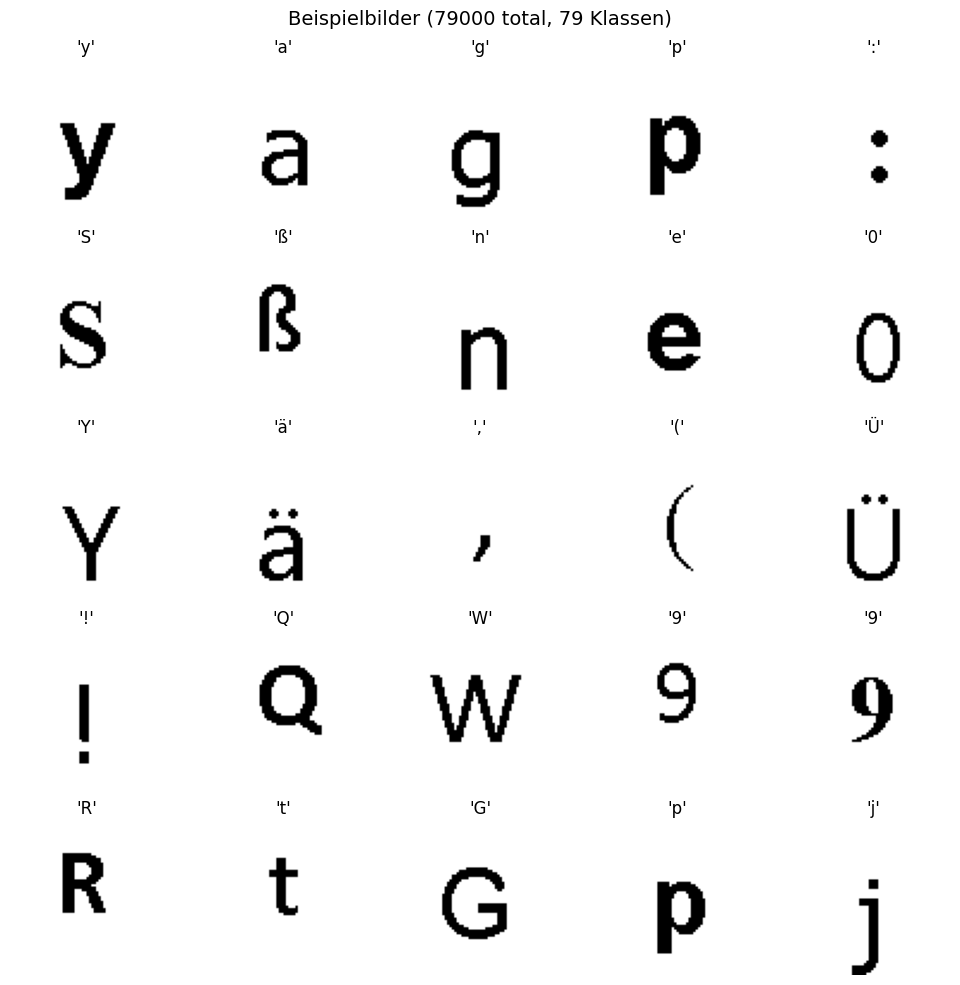

In [24]:
# Datensatz laden
data = np.load(OUTPUT_PATH, allow_pickle=True)
X = data['X']
y = data['y']
chars = data['chars']

# 25 zufällige Bilder auswählen
indices = random.sample(range(len(X)), 25)

# 5x5 Grid erstellen
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    axes[i].imshow(X[idx], cmap='gray')
    axes[i].set_title(f"'{chars[y[idx]]}'", fontsize=12)
    axes[i].axis('off')

plt.suptitle(f"Beispielbilder ({len(X)} total, {len(chars)} Klassen)", fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
DATA_PATH = FILENAME

# Where to save the model checkpoints
CHECKPOINT_DIR = 'checkpoint'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 20
TEST_SPLIT = 0.2  # 20% for testing

In [22]:
# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
print(f"\nLoading data from {DATA_PATH}...")

try:
    data = np.load(DATA_PATH, allow_pickle=True)
    X = data['X']
    y = data['y']
    chars = data['chars']
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: File not found at {DATA_PATH}. Please check the path.")
    raise

# Normalize images: Convert 0-255 to 0.0-1.0 (Crucial for Neural Networks)
print("Normalizing images...")
X = X.astype('float32') / 255.0

# Reshape: Add the 'Channel' dimension.
# TensorFlow expects (Batch, Height, Width, Channels) -> (N, 128, 128, 1)
# If your images are grayscale, channels = 1.
if len(X.shape) == 3:
    X = np.expand_dims(X, axis=-1)

print(f"Input Shape: {X.shape}")

# One-Hot Encoding for Labels
num_classes = len(chars)
print(f"Number of classes: {num_classes}")
y = keras.utils.to_categorical(y, num_classes)

# Split into Train and Test sets
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")



Loading data from dataset_aligned.npz...
Data loaded successfully.
Normalizing images...
Input Shape: (79000, 64, 64, 1)
Number of classes: 79
Splitting data...
Training samples: 63200
Testing samples: 15800


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 79)             │        40,527 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,328,015 (16.51 MB)

 Trainable params: 4,328,015 (16.51 MB)

 Non-trainable params: 0 (0.00 B)


Starting training (64px input)...
Epoch 1/20
988/988 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6607 - loss: 1.3503
Epoch 1: saving model to checkpoint\model_epoch_01_val_acc_0.99.keras

Epoch 1: finished saving model to checkpoint\model_epoch_01_val_acc_0.99.keras
988/988 ━━━━━━━━━━━━━━━━━━━━ 112s 107ms/step - accuracy: 0.8670 - loss: 0.4949 - val_accuracy: 0.9915 - val_loss: 0.0221
Epoch 2/20
988/988 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9824 - loss: 0.0516
Epoch 2: saving model to checkpoint\model_epoch_02_val_acc_0.99.keras

Epoch 2: finished saving model to checkpoint\model_epoch_02_val_acc_0.99.keras
988/988 ━━━━━━━━━━━━━━━━━━━━ 100s 101ms/step - accuracy: 0.9838 - loss: 0.0468 - val_accuracy: 0.9922 - val_loss: 0.0169
Epoch 3/20
988/988 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9893 - loss: 0.0308
Epoch 3: saving model to checkpoint\model_epoch_03_val_acc_0.99.keras

Epoch 3: finished saving model to checkpoint\model_epoch_03_val_acc_0.99.keras
988/988 ━━━━

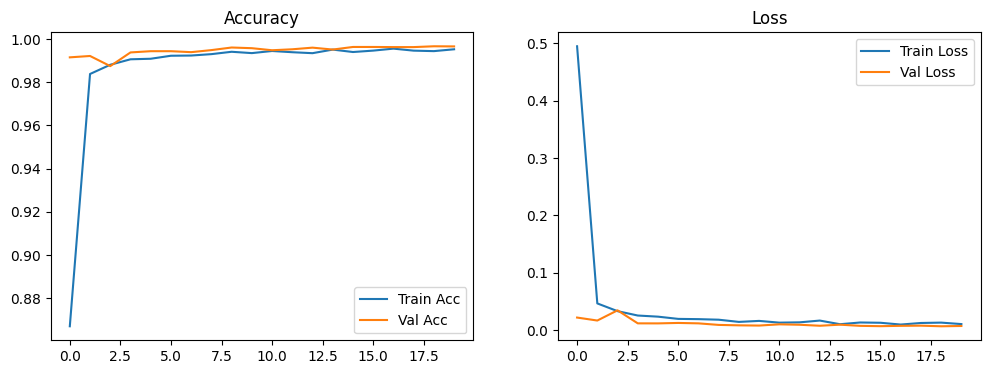

In [23]:

# ==========================================
# MODEL DEFINITION (64x64 INPUT)
# ==========================================
model = models.Sequential([
    # Block 1
    # CHANGED: input_shape is now (64, 64, 1)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)), # Output: 32x32

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Output: 16x16

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Output: 8x8

    # Block 4
    #layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    #layers.MaxPooling2D((2, 2)), # Output: 4x4

    # Flatten & Dense Layers
    layers.Flatten(),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(512, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Output layer
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 4. CALLBACKS (SAVING & LOGGING)
# ==========================================

# Ensure checkpoint dir exists
if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)

# Checkpoint: Save model
checkpoint_path = os.path.join(CHECKPOINT_DIR, "model_epoch_{epoch:02d}_val_acc_{val_accuracy:.2f}.keras")

checkpoint_callback = callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=False,
    verbose=1
)

# Early Stopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ==========================================
# 5. TRAINING
# ==========================================
print("\nStarting training (64px input)...")

# Note: With smaller images (64px), you can often increase BATCH_SIZE
# (e.g., to 64 or 128) to speed up training if your RAM allows.
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback, early_stopping]
)

# ==========================================
# 6. EVALUATION & SAVING FINAL MODEL
# ==========================================
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save the final model explicitly
final_save_path = os.path.join(CHECKPOINT_DIR, 'final_german_ocr_model_64px.keras')
model.save(final_save_path)
print(f"Final model saved to: {final_save_path}")

# Plot History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()